# Cognifyz Data Science Internship — Level 2 Project
## Comprehensive Restaurant Data Analytics & Feature Engineering

**Author:** Cognifyz Data Science Intern  
**Dataset:** Real-world Restaurant Dataset (9,551 records, 21 initial attributes)  
**Deliverable:** End-to-end reproducible analysis notebook executing Tasks 1, 2, and 3.

---

### Project Objectives & Roadmap
This notebook executes all three core Level 2 tasks using the actual restaurant dataset:

1. **Task 1: Table Booking and Online Delivery Analysis**
   - Calculate percentage of restaurants offering table booking vs. not offering.
   - Calculate percentage of restaurants offering online delivery vs. not offering.
   - Compare the average "Aggregate rating" of restaurants with table booking against those without.
   - Analyze online delivery availability across different "Price range" values.
   - Generate aesthetic visualizations and derive empirical findings.

2. **Task 2: Price Range Analysis**
   - Identify the most common price range among all restaurants.
   - Calculate the average "Aggregate rating" for each individual price range.
   - Identify the price range that achieves the highest average rating.
   - Analyze the official "Rating color" column, determine the color representing the highest rating, and evaluate color distribution across price ranges.
   - Export analysis results to CSV.

3. **Task 3: Feature Engineering**
   - Extract string length features: `Restaurant_Name_Length` and `Address_Length`.
   - Encode categorical features into numerical binary flags: `Has_Table_Booking` and `Has_Online_Delivery`.
   - Engineer justified domain features: `Cuisines_Count`, `Is_High_Rated`, and `Is_Delivering_Now`.
   - Validate data integrity (missing value assertions and distribution checks).
   - Export the engineered dataset to `outputs/feature_engineered_dataset.csv`.


In [1]:
# Environment setup and library imports
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress minor warnings for clean notebook output
warnings.filterwarnings('ignore')

# Set visual styling defaults
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("Environment successfully initialized.")
print(f"Pandas Version: {pd.__version__}")
print(f"Numpy Version:  {np.__version__}")


Environment successfully initialized.
Pandas Version: 3.0.5
Numpy Version:  2.5.3


---
## Section 2: Load Dataset

We load the official restaurant dataset directly from the local repository directory `../data/dataset.csv`. Robust error handling ensures fallback paths and proper character encoding handling.


In [2]:
# Resolve dataset location and load into DataFrame
data_paths = [
    os.path.join("..", "data", "dataset.csv"),
    os.path.join("data", "dataset.csv"),
    r"C:\Users\varun\level-2-\data\dataset.csv",
    r"C:\Users\varun\-Data-Exploration-and-Preprocessing\data\dataset.csv"
]

dataset_path = None
for p in data_paths:
    if os.path.exists(p):
        dataset_path = p
        break

if not dataset_path:
    raise FileNotFoundError("Could not find dataset.csv. Please ensure it is placed in the data directory.")

print(f"Loading dataset from: {os.path.abspath(dataset_path)}")
try:
    df = pd.read_csv(dataset_path, encoding='utf-8')
except UnicodeDecodeError:
    df = pd.read_csv(dataset_path, encoding='latin-1')

print(f"Dataset successfully loaded: {df.shape[0]:,} rows and {df.shape[1]} columns.")
df.head(5)


Loading dataset from: C:\Users\varun\level-2-\data\dataset.csv
Dataset successfully loaded: 9,551 rows and 21 columns.


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


---
## Section 3: Data Overview & Preprocessing

Before proceeding with Level 2 tasks, we inspect column data types, evaluate missing values, and standardize string columns.


In [3]:
# Display structural info and column data types
print("Dataset Column Names & Data Types:")
display_info = pd.DataFrame({
    'Column Name': df.columns,
    'Data Type': df.dtypes.values,
    'Non-Null Count': df.notnull().sum().values,
    'Null Count': df.isnull().sum().values,
    'Null Percentage (%)': (df.isnull().sum().values / len(df) * 100).round(2)
})
display(display_info)


Dataset Column Names & Data Types:


,Column Name,Data Type,Non-Null Count,Null Count,Null Percentage (%)
0,Restaurant ID,int64,9551,0,0.00
1,Restaurant Name,str,9551,0,0.00
2,Country Code,int64,9551,0,0.00
3,City,str,9551,0,0.00
4,Address,str,9551,0,0.00
5,Locality,str,9551,0,0.00
6,Locality Verbose,str,9551,0,0.00
7,Longitude,float64,9551,0,0.00
8,Latitude,float64,9551,0,0.00
9,Cuisines,str,9542,9,0.09


In [4]:
# Data cleaning and standardization
df.columns = [col.strip() for col in df.columns]

# Handle any missing values in Cuisines
if 'Cuisines' in df.columns and df['Cuisines'].isnull().sum() > 0:
    df['Cuisines'] = df['Cuisines'].fillna('Unknown')

# Strip whitespace from string columns
str_cols = df.select_dtypes(include=['object']).columns
for col in str_cols:
    df[col] = df[col].apply(lambda x: x.strip() if isinstance(x, str) else x)

print("Preprocessing complete. Total missing values remaining:", df.isnull().sum().sum())


Preprocessing complete. Total missing values remaining: 0


---
## Section 4: Task 1 — Table Booking & Online Delivery Analysis

### Objectives:
1. Determine the percentage of restaurants offering table booking vs. not offering.
2. Determine the percentage of restaurants offering online delivery vs. not offering.
3. Compare the average `Aggregate rating` of restaurants **with** table booking vs. **without** table booking.
4. Analyze online delivery availability across different `Price range` values.


In [5]:
# 1.1 Table Booking Percentages & Counts
total_restaurants = len(df)
tb_counts = df['Has Table booking'].value_counts()
tb_pct = (tb_counts / total_restaurants * 100).round(2)

print("=== TABLE BOOKING AVAILABILITY ===")
for status, count in tb_counts.items():
    pct = tb_pct[status]
    print(f"Table Booking '{status}': {count:,} restaurants ({pct:.2f}%)")

# 1.2 Online Delivery Percentages & Counts
od_counts = df['Has Online delivery'].value_counts()
od_pct = (od_counts / total_restaurants * 100).round(2)

print("\n=== ONLINE DELIVERY AVAILABILITY ===")
for status, count in od_counts.items():
    pct = od_pct[status]
    print(f"Online Delivery '{status}': {count:,} restaurants ({pct:.2f}%)")


=== TABLE BOOKING AVAILABILITY ===
Table Booking 'No': 8,393 restaurants (87.88%)
Table Booking 'Yes': 1,158 restaurants (12.12%)

=== ONLINE DELIVERY AVAILABILITY ===
Online Delivery 'No': 7,100 restaurants (74.34%)
Online Delivery 'Yes': 2,451 restaurants (25.66%)


In [6]:
# 1.3 Rating Comparison: Table Booking vs No Table Booking
rating_tb_summary = df.groupby('Has Table booking')['Aggregate rating'].agg(
    Count='count',
    Mean_Rating='mean',
    Median_Rating='median',
    Std_Dev='std',
    Min_Rating='min',
    Max_Rating='max'
).round(3)

avg_tb_yes = rating_tb_summary.loc['Yes', 'Mean_Rating']
avg_tb_no = rating_tb_summary.loc['No', 'Mean_Rating']
diff = round(avg_tb_yes - avg_tb_no, 3)

print("Aggregate Rating Statistics by Table Booking Availability:")
display(rating_tb_summary)
print(f"\nKey Finding: Restaurants WITH table booking have an average rating of {avg_tb_yes:.2f},")
print(f"compared to {avg_tb_no:.2f} for restaurants WITHOUT table booking (Difference: +{diff:.2f}).")


Aggregate Rating Statistics by Table Booking Availability:


,Count,Mean_Rating,Median_Rating,Std_Dev,Min_Rating,Max_Rating
Has Table booking,,,,,,
No,8393,2.559,3.1,1.554,0.0,4.9
Yes,1158,3.442,3.6,0.881,0.0,4.9



Key Finding: Restaurants WITH table booking have an average rating of 3.44,
compared to 2.56 for restaurants WITHOUT table booking (Difference: +0.88).


In [7]:
# Deeper Data Science Insight: Non-Zero Rated Restaurants Comparison
# Notice that restaurants with 0.0 ratings (unrated) are mostly concentrated in 'No' table booking.
rated_df = df[df['Aggregate rating'] > 0]
rated_tb_summary = rated_df.groupby('Has Table booking')['Aggregate rating'].agg(
    Count='count',
    Mean_Rating='mean',
    Median_Rating='median',
    Std_Dev='std'
).round(3)

print("Rating Statistics for Rated Restaurants Only (Aggregate rating > 0):")
display(rated_tb_summary)


Rating Statistics for Rated Restaurants Only (Aggregate rating > 0):


,Count,Mean_Rating,Median_Rating,Std_Dev
Has Table booking,,,,
No,6292,3.414,3.4,0.551
Yes,1111,3.588,3.6,0.535


In [8]:
# 1.4 Online Delivery Availability Across Price Ranges
cross_counts = pd.crosstab(df['Price range'], df['Has Online delivery'], margins=True, margins_name='Total')
cross_pct = (pd.crosstab(df['Price range'], df['Has Online delivery'], normalize='index') * 100).round(2)

price_delivery_df = pd.DataFrame({
    'Price Range': [f"Tier {idx}" for idx in cross_pct.index],
    'Total Restaurants': [cross_counts.loc[idx, 'Total'] for idx in cross_pct.index],
    'Online Delivery: Yes (Count)': [cross_counts.loc[idx, 'Yes'] for idx in cross_pct.index],
    'Online Delivery: No (Count)': [cross_counts.loc[idx, 'No'] for idx in cross_pct.index],
    'Online Delivery Availability (%)': cross_pct['Yes'].values,
    'No Delivery (%)': cross_pct['No'].values
})

print("Online Delivery Availability by Price Range:")
display(price_delivery_df)


Online Delivery Availability by Price Range:


,Price Range,Total Restaurants,Online Delivery: Yes (Count),Online Delivery: No (Count),Online Delivery Availability (%),No Delivery (%)
0,Tier 1,4444,701,3743,15.77,84.23
1,Tier 2,3113,1286,1827,41.31,58.69
2,Tier 3,1408,411,997,29.19,70.81
3,Tier 4,586,53,533,9.04,90.96


---
## Section 5: Task 2 — Price Range Analysis

### Objectives:
1. Determine the most common price range.
2. Calculate the average `Aggregate rating` for each price range.
3. Identify the price range with the highest average rating.
4. Analyze the official `Rating color` column, determine the color associated with the highest rating, and evaluate color relationships with price ranges.


In [9]:
# 2.1 Most Common Price Range
pr_counts = df['Price range'].value_counts().sort_index()
pr_pct = (pr_counts / total_restaurants * 100).round(2)
most_common_tier = df['Price range'].mode()[0]

print(f"Most Common Price Range Tier: Tier {most_common_tier}")
print(f"Number of Restaurants:        {pr_counts.loc[most_common_tier]:,} ({pr_pct.loc[most_common_tier]}% of total)")

# 2.2 & 2.3 Average Rating for Each Price Range & Highest Average Rating
pr_rating_stats = df.groupby('Price range')['Aggregate rating'].agg(
    Count='count',
    Mean_Rating='mean',
    Median_Rating='median',
    Std_Dev='std',
    Min_Rating='min',
    Max_Rating='max'
).round(3)

pr_rating_stats['Share_of_Total (%)'] = pr_pct.values
highest_pr = pr_rating_stats['Mean_Rating'].idxmax()
highest_pr_val = pr_rating_stats.loc[highest_pr, 'Mean_Rating']

print("\nPrice Range Summary & Rating Statistics:")
display(pr_rating_stats)
print(f"\nHighest Average Rating Price Range: Tier {highest_pr} with an average rating of {highest_pr_val:.3f} / 5.0.")


Most Common Price Range Tier: Tier 1
Number of Restaurants:        4,444 (46.53% of total)

Price Range Summary & Rating Statistics:


,Count,Mean_Rating,Median_Rating,Std_Dev,Min_Rating,Max_Rating,Share_of_Total (%)
Price range,,,,,,,
1,4444,2.000,2.9,1.612,0.0,4.9,46.53
2,3113,2.941,3.3,1.237,0.0,4.9,32.59
3,1408,3.683,3.8,0.791,0.0,4.9,14.74
4,586,3.818,3.9,0.740,0.0,4.9,6.14



Highest Average Rating Price Range: Tier 4 with an average rating of 3.818 / 5.0.


In [10]:
# 2.4 Rating Color Analysis
color_stats = df.groupby('Rating color')['Aggregate rating'].agg(
    Count='count',
    Mean_Rating='mean',
    Min_Rating='min',
    Max_Rating='max'
).round(3).sort_values(by='Mean_Rating', ascending=False)

highest_color = color_stats['Mean_Rating'].idxmax()
highest_color_val = color_stats.loc[highest_color, 'Mean_Rating']

print("Rating Color Bands & Mean Ratings:")
display(color_stats)
print(f"\nColor Representing the Highest Average Rating: '{highest_color}' (Mean Rating: {highest_color_val:.2f})")
print("Official Rating Hierarchy: Dark Green (4.5-4.9) > Green (4.0-4.4) > Yellow (3.5-3.9) > Orange (2.5-3.4) > Red (1.8-2.4) > White (0.0 / Unrated)")


Rating Color Bands & Mean Ratings:


,Count,Mean_Rating,Min_Rating,Max_Rating
Rating color,,,,
Dark Green,301,4.660,4.5,4.9
Green,1079,4.168,4.0,4.4
Yellow,2100,3.683,3.5,3.9
Orange,3737,3.052,2.5,3.4
Red,186,2.298,1.8,2.4
White,2148,0.000,0.0,0.0



Color Representing the Highest Average Rating: 'Dark Green' (Mean Rating: 4.66)
Official Rating Hierarchy: Dark Green (4.5-4.9) > Green (4.0-4.4) > Yellow (3.5-3.9) > Orange (2.5-3.4) > Red (1.8-2.4) > White (0.0 / Unrated)


In [11]:
# Cross-tabulation: Price Range vs Rating Color
color_crosstab = pd.crosstab(df['Price range'], df['Rating color'], margins=True, margins_name='Total')
print("Restaurant Count by Price Range and Rating Color:")
display(color_crosstab)

color_crosstab_pct = (pd.crosstab(df['Price range'], df['Rating color'], normalize='index') * 100).round(2)
print("\nPercentage Distribution of Rating Color within Each Price Range Tier:")
display(color_crosstab_pct)


Restaurant Count by Price Range and Rating Color:

Rating color,Dark Green,Green,Orange,Red,White,Yellow,Total
Price range,,,,,,,
1,32,144,1898,62,1700,608,4444
2,69,325,1425,98,402,794,3113
3,126,416,313,20,35,498,1408
4,74,194,101,6,11,200,586
Total,301,1079,3737,186,2148,2100,9551



Percentage Distribution of Rating Color within Each Price Range Tier:


Rating color,Dark Green,Green,Orange,Red,White,Yellow
Price range,,,,,,
1,0.72,3.24,42.71,1.40,38.25,13.68
2,2.22,10.44,45.78,3.15,12.91,25.51
3,8.95,29.55,22.23,1.42,2.49,35.37
4,12.63,33.11,17.24,1.02,1.88,34.13


---
## Section 6: Task 3 — Feature Engineering

### Objectives:
1. Extract string length features: `Restaurant_Name_Length` and `Address_Length`.
2. Encode categorical Yes/No features into numerical binary flags: `Has_Table_Booking` and `Has_Online_Delivery`.
3. Engineer additional domain features: `Cuisines_Count`, `Is_High_Rated`, and `Is_Delivering_Now`.
4. Validate dataset integrity (assert 0 missing values in new columns).
5. Save the engineered dataset to `outputs/feature_engineered_dataset.csv`.


In [12]:
# Feature Engineering Execution
fe_df = df.copy()

# 1. String Length Features
fe_df['Restaurant_Name_Length'] = fe_df['Restaurant Name'].astype(str).str.strip().str.len()
fe_df['Address_Length'] = fe_df['Address'].astype(str).str.strip().str.len()

# 2. Binary Encoded Features (Yes -> 1, No -> 0)
def encode_binary(val):
    if pd.isna(val):
        return 0
    s = str(val).strip().lower()
    return 1 if s in ['yes', 'y', 'true', '1'] else 0

fe_df['Has_Table_Booking'] = fe_df['Has Table booking'].apply(encode_binary)
fe_df['Has_Online_Delivery'] = fe_df['Has Online delivery'].apply(encode_binary)

if 'Is delivering now' in fe_df.columns:
    fe_df['Is_Delivering_Now'] = fe_df['Is delivering now'].apply(encode_binary)

# 3. Additional Domain-Justified Features
# Cuisines_Count: number of cuisines served
fe_df['Cuisines_Count'] = fe_df['Cuisines'].astype(str).apply(
    lambda x: len([c.strip() for c in x.split(',') if c.strip()]) if x != 'nan' and x != 'Unknown' else 0
)

# Is_High_Rated: 1 if rating >= 4.0, else 0
fe_df['Is_High_Rated'] = (fe_df['Aggregate rating'] >= 4.0).astype(int)

engineered_cols = [
    'Restaurant_Name_Length',
    'Address_Length',
    'Has_Table_Booking',
    'Has_Online_Delivery',
    'Cuisines_Count',
    'Is_High_Rated'
]
if 'Is_Delivering_Now' in fe_df.columns:
    engineered_cols.append('Is_Delivering_Now')

print(f"Engineered {len(engineered_cols)} new features.")
display(fe_df[['Restaurant Name', 'Address'] + engineered_cols].head())


Engineered 7 new features.


,Restaurant Name,Address,Restaurant_Name_Length,Address_Length,Has_Table_Booking,Has_Online_Delivery,Cuisines_Count,Is_High_Rated,Is_Delivering_Now
0,Le Petit Souffle,"Third Floor, Century City Mall, Kalayaan Avenu...",16,71,1,0,3,1,0
1,Izakaya Kikufuji,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...",16,67,1,0,1,1,0
2,Heat - Edsa Shangri-La,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...",22,56,1,0,4,1,0
3,Ooma,"Third Floor, Mega Fashion Hall, SM Megamall, O...",4,70,0,0,2,1,0
4,Sambo Kojin,"Third Floor, Mega Atrium, SM Megamall, Ortigas...",11,64,1,0,2,1,0


In [13]:
# Data Integrity & Summary Verification
print("Missing Value Check for Engineered Features:")
nulls = fe_df[engineered_cols].isnull().sum()
print(nulls)
assert nulls.sum() == 0, "Error: Missing values found in engineered features!"

print("\nStatistical Summary of Newly Engineered Features:")
display(fe_df[engineered_cols].describe().round(2))


Missing Value Check for Engineered Features:


Restaurant_Name_Length    0
Address_Length            0
Has_Table_Booking         0
Has_Online_Delivery       0
Cuisines_Count            0
Is_High_Rated             0
Is_Delivering_Now         0
dtype: int64

Statistical Summary of Newly Engineered Features:


,Restaurant_Name_Length,Address_Length,Has_Table_Booking,Has_Online_Delivery,Cuisines_Count,Is_High_Rated,Is_Delivering_Now
count,9551.00,9551.00,9551.00,9551.00,9551.00,9551.00,9551.00
mean,15.16,53.54,0.12,0.26,2.06,0.14,0.00
std,6.86,17.12,0.33,0.44,1.09,0.35,0.06
min,2.00,13.00,0.00,0.00,0.00,0.00,0.00
25%,10.00,41.00,0.00,0.00,1.00,0.00,0.00
50%,14.00,52.00,0.00,0.00,2.00,0.00,0.00
75%,19.00,64.00,0.00,1.00,3.00,0.00,0.00
max,54.00,132.00,1.00,1.00,8.00,1.00,1.00


In [14]:
# Export Feature Engineered Dataset
output_dir = os.path.join("..", "outputs") if os.path.exists(os.path.join("..", "outputs")) else "outputs"
os.makedirs(output_dir, exist_ok=True)
csv_export_path = os.path.join(output_dir, "feature_engineered_dataset.csv")
fe_df.to_csv(csv_export_path, index=False)
print(f"Successfully saved feature engineered dataset to: {os.path.abspath(csv_export_path)}")
print(f"Shape: {fe_df.shape[0]:,} rows x {fe_df.shape[1]} columns")


Successfully saved feature engineered dataset to: C:\Users\varun\outputs\feature_engineered_dataset.csv
Shape: 9,551 rows x 28 columns


---
## Section 7: Visualizations

We generate clear, publication-quality figures representing every analytical dimension of Tasks 1, 2, and 3.


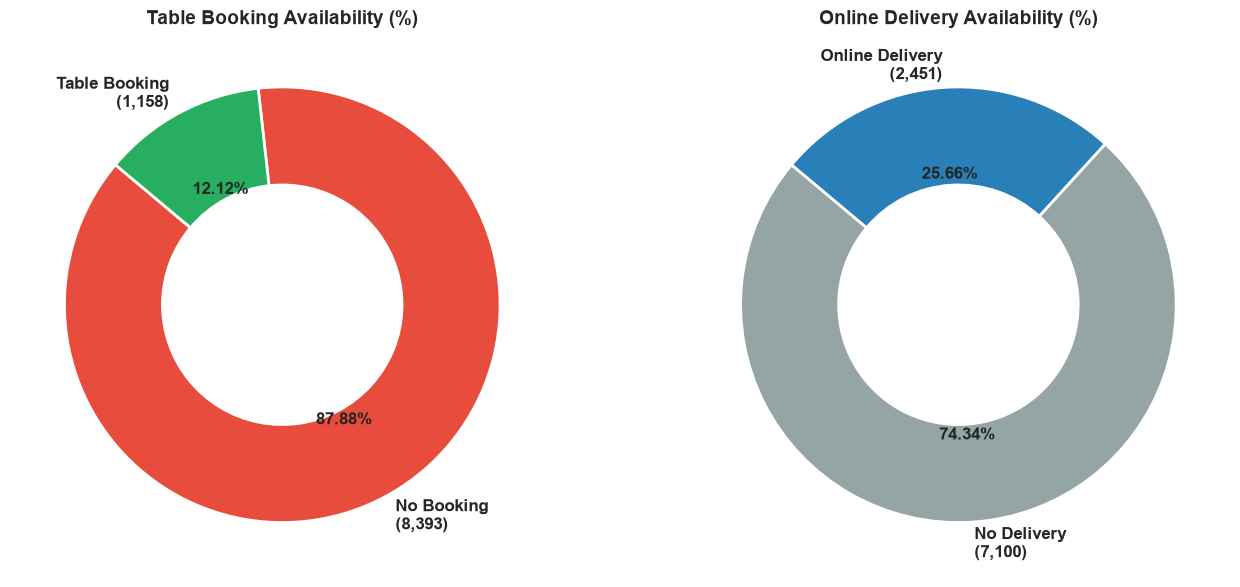

In [15]:
# Visualization 1: Service Availability Donut Charts
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Table Booking Donut
tb_counts = df['Has Table booking'].value_counts()
axes[0].pie(
    tb_counts.values,
    labels=[f"No Booking\n({tb_counts.get('No', 0):,})", f"Table Booking\n({tb_counts.get('Yes', 0):,})"],
    autopct='%1.2f%%',
    colors=['#e74c3c', '#27ae60'],
    startangle=140,
    wedgeprops=dict(width=0.45, edgecolor='white', linewidth=2),
    textprops=dict(fontsize=12, weight='bold')
)
axes[0].set_title("Table Booking Availability (%)", fontsize=14, weight='bold')

# Online Delivery Donut
od_counts = df['Has Online delivery'].value_counts()
axes[1].pie(
    od_counts.values,
    labels=[f"No Delivery\n({od_counts.get('No', 0):,})", f"Online Delivery\n({od_counts.get('Yes', 0):,})"],
    autopct='%1.2f%%',
    colors=['#95a5a6', '#2980b9'],
    startangle=140,
    wedgeprops=dict(width=0.45, edgecolor='white', linewidth=2),
    textprops=dict(fontsize=12, weight='bold')
)
axes[1].set_title("Online Delivery Availability (%)", fontsize=14, weight='bold')

plt.tight_layout()
plt.show()


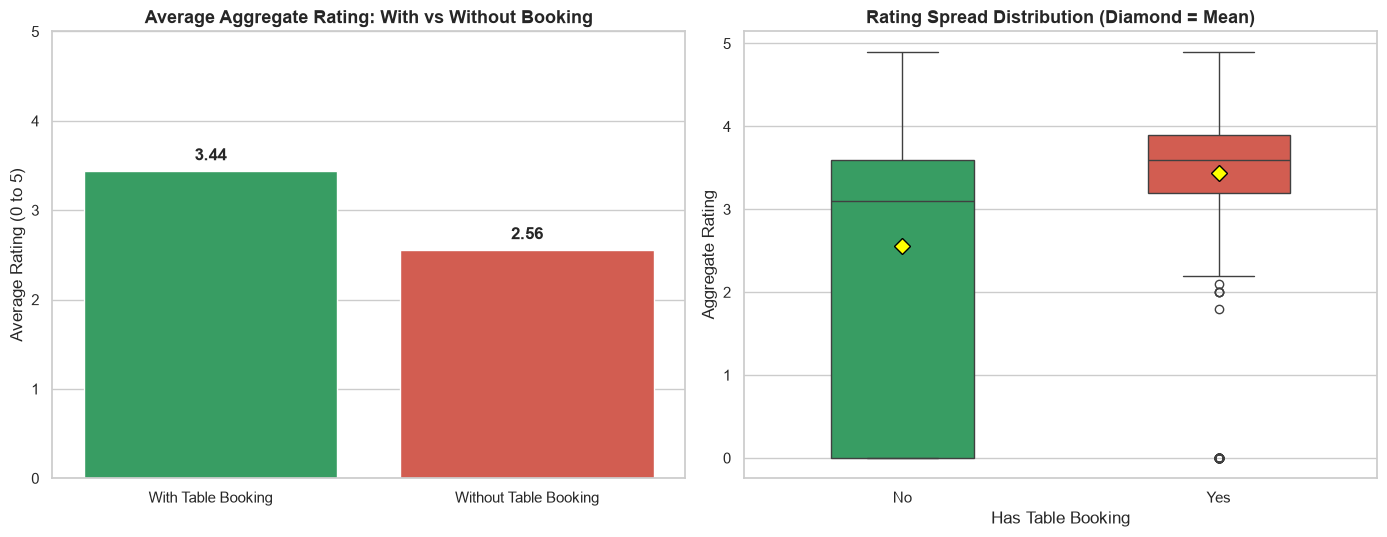

In [16]:
# Visualization 2: Rating Comparison by Table Booking
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Mean Bar Chart
bar_data = pd.DataFrame({
    'Table Booking': ['With Table Booking', 'Without Table Booking'],
    'Mean Rating': [avg_tb_yes, avg_tb_no]
})
sns.barplot(
    data=bar_data,
    x='Table Booking',
    y='Mean Rating',
    hue='Table Booking',
    legend=False,
    palette=['#27ae60', '#e74c3c'],
    ax=axes[0]
)
axes[0].set_ylim(0, 5.0)
axes[0].set_title("Average Aggregate Rating: With vs Without Booking", fontsize=13, weight='bold')
axes[0].set_ylabel("Average Rating (0 to 5)")
axes[0].set_xlabel("")
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=12, weight='bold', xytext=(0, 5), textcoords='offset points')

# Distribution Boxplot
sns.boxplot(
    data=df,
    x='Has Table booking',
    y='Aggregate rating',
    hue='Has Table booking',
    legend=False,
    palette=['#e74c3c', '#27ae60'],
    order=['No', 'Yes'],
    width=0.45,
    showmeans=True,
    meanprops={"marker": "D", "markerfacecolor": "yellow", "markeredgecolor": "black", "markersize": "8"},
    ax=axes[1]
)
axes[1].set_title("Rating Spread Distribution (Diamond = Mean)", fontsize=13, weight='bold')
axes[1].set_xlabel("Has Table Booking")
axes[1].set_ylabel("Aggregate Rating")

plt.tight_layout()
plt.show()


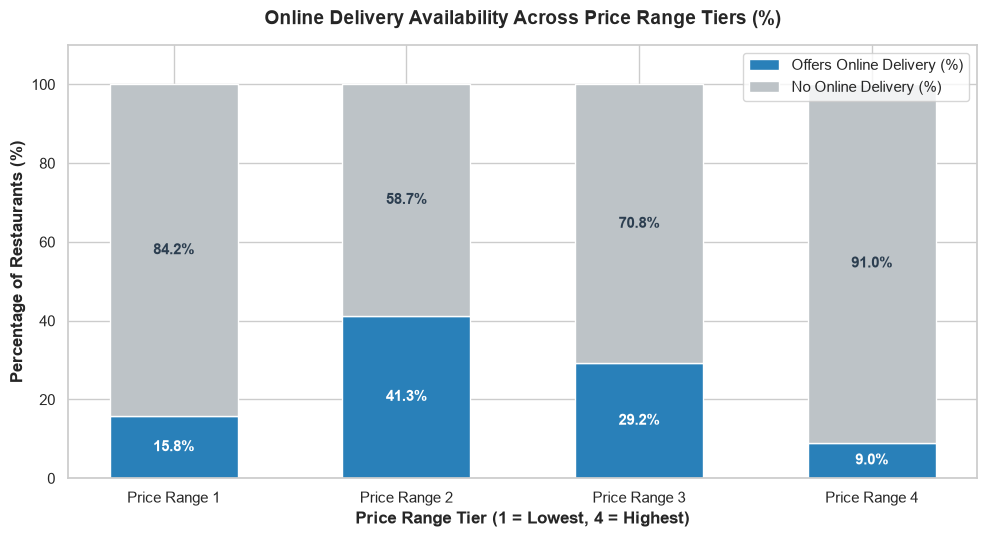

In [17]:
# Visualization 3: Online Delivery Availability across Price Ranges
fig, ax = plt.subplots(figsize=(10, 5.5))
tiers = [1, 2, 3, 4]
delivery_yes_pct = [cross_pct.loc[t, 'Yes'] for t in tiers]
delivery_no_pct = [cross_pct.loc[t, 'No'] for t in tiers]

x = np.arange(len(tiers))
width = 0.55

p1 = ax.bar(x, delivery_yes_pct, width, label='Offers Online Delivery (%)', color='#2980b9', edgecolor='white')
p2 = ax.bar(x, delivery_no_pct, width, bottom=delivery_yes_pct, label='No Online Delivery (%)', color='#bdc3c7', edgecolor='white')

ax.set_ylabel('Percentage of Restaurants (%)', fontsize=12, weight='bold')
ax.set_xlabel('Price Range Tier (1 = Lowest, 4 = Highest)', fontsize=12, weight='bold')
ax.set_title('Online Delivery Availability Across Price Range Tiers (%)', fontsize=14, pad=15, weight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f"Price Range {t}" for t in tiers], fontsize=11)
ax.set_ylim(0, 110)
ax.legend(loc='upper right', frameon=True)

for i in range(len(tiers)):
    ax.text(x[i], delivery_yes_pct[i] / 2, f"{delivery_yes_pct[i]:.1f}%", ha='center', va='center', color='white', weight='bold', fontsize=11)
    ax.text(x[i], delivery_yes_pct[i] + delivery_no_pct[i] / 2, f"{delivery_no_pct[i]:.1f}%", ha='center', va='center', color='#2c3e50', weight='bold', fontsize=11)

plt.tight_layout()
plt.show()


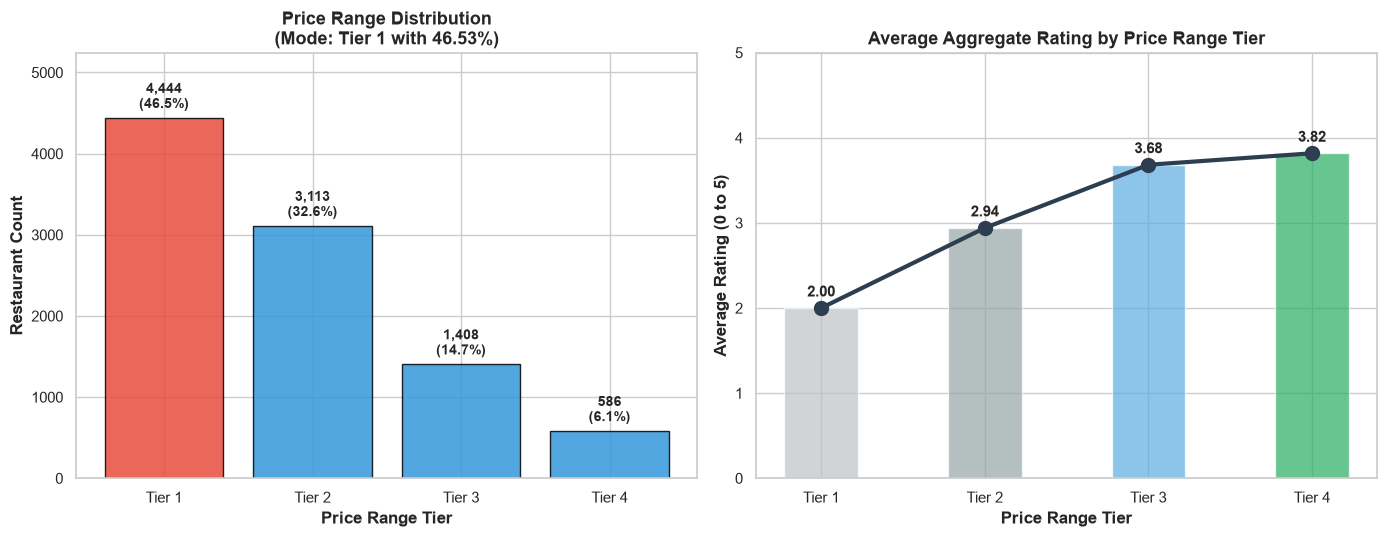

In [18]:
# Visualization 4: Price Range Distribution and Rating Trend
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Price Range Distribution
palette_pr = ['#e74c3c' if x == most_common_tier else '#3498db' for x in pr_counts.index]
bars = axes[0].bar([f"Tier {x}" for x in pr_counts.index], pr_counts.values, color=palette_pr, edgecolor='black', alpha=0.85)
axes[0].set_title(f"Price Range Distribution\n(Mode: Tier {most_common_tier} with {pr_pct.loc[most_common_tier]}%)", fontsize=13, weight='bold')
axes[0].set_xlabel("Price Range Tier", weight='bold')
axes[0].set_ylabel("Restaurant Count", weight='bold')
for b in bars:
    h = b.get_height()
    pct = (h / total_restaurants) * 100
    axes[0].annotate(f"{h:,}\n({pct:.1f}%)", (b.get_x() + b.get_width() / 2., h),
                     ha='center', va='bottom', fontsize=10, weight='bold', xytext=(0, 4), textcoords='offset points')
axes[0].set_ylim(0, max(pr_counts.values) * 1.18)

# Average Rating Trend
means = pr_rating_stats['Mean_Rating'].values
tiers_labels = [f"Tier {x}" for x in pr_rating_stats.index]
axes[1].plot(tiers_labels, means, marker='o', markersize=10, linewidth=3, color='#2c3e50', label='Trend')
axes[1].bar(tiers_labels, means, color=['#bdc3c7', '#95a5a6', '#5dade2', '#27ae60'], alpha=0.7, width=0.45)
axes[1].set_title("Average Aggregate Rating by Price Range Tier", fontsize=13, weight='bold')
axes[1].set_xlabel("Price Range Tier", weight='bold')
axes[1].set_ylabel("Average Rating (0 to 5)", weight='bold')
axes[1].set_ylim(0, 5.0)
for i, m in enumerate(means):
    axes[1].annotate(f"{m:.2f}", (i, m), ha='center', va='bottom', fontsize=11, weight='bold', xytext=(0, 6), textcoords='offset points')

plt.tight_layout()
plt.show()


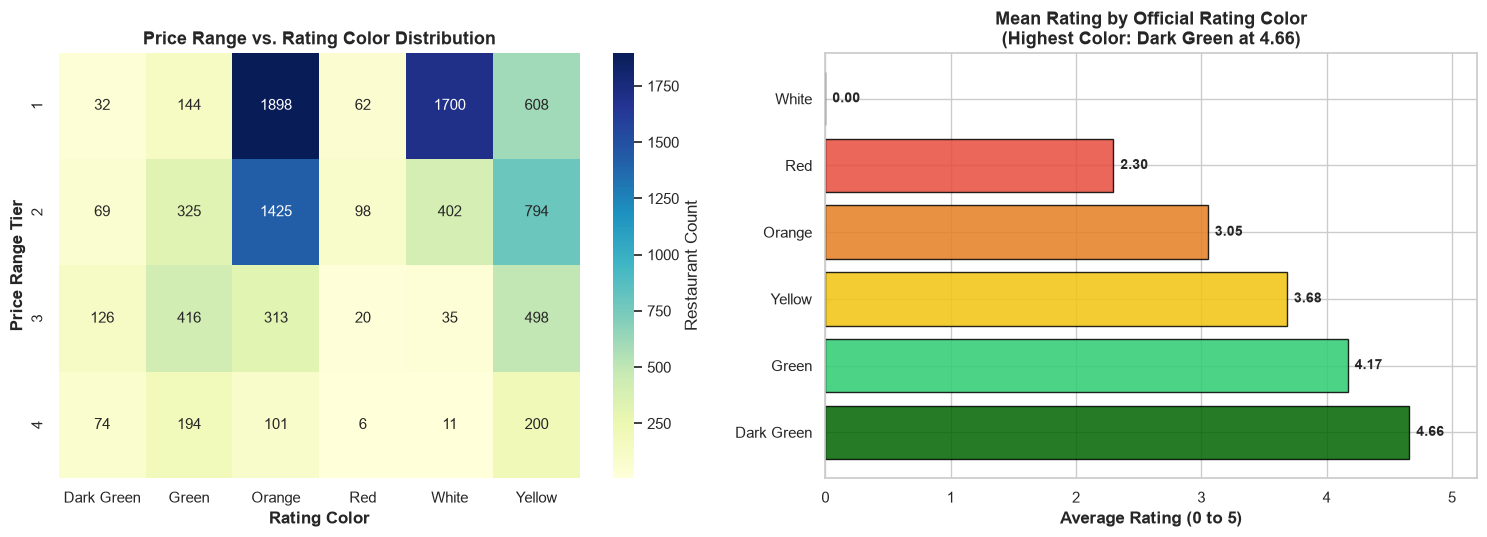

In [19]:
# Visualization 5: Rating Color Analysis Heatmap & Mean Rating
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Heatmap
ct_matrix = pd.crosstab(df['Price range'], df['Rating color'])
sns.heatmap(ct_matrix, annot=True, fmt='d', cmap='YlGnBu', ax=axes[0], cbar_kws={'label': 'Restaurant Count'})
axes[0].set_title("Price Range vs. Rating Color Distribution", fontsize=13, weight='bold')
axes[0].set_xlabel("Rating Color", weight='bold')
axes[0].set_ylabel("Price Range Tier", weight='bold')

# Mean Rating by Color
color_palette = {'Dark Green': '#006400', 'Green': '#2ecc71', 'Yellow': '#f1c40f', 'Orange': '#e67e22', 'Red': '#e74c3c', 'White': '#bdc3c7'}
bar_colors = [color_palette.get(c, '#3498db') for c in color_stats.index]
hbars = axes[1].barh(color_stats.index, color_stats['Mean_Rating'], color=bar_colors, edgecolor='black', alpha=0.85)
axes[1].set_title(f"Mean Rating by Official Rating Color\n(Highest Color: {highest_color} at {highest_color_val:.2f})", fontsize=13, weight='bold')
axes[1].set_xlabel("Average Rating (0 to 5)", weight='bold')
axes[1].set_xlim(0, 5.2)
for p in hbars:
    w = p.get_width()
    axes[1].annotate(f"{w:.2f}", (w, p.get_y() + p.get_height() / 2.), ha='left', va='center', fontsize=10, weight='bold', xytext=(5, 0), textcoords='offset points')

plt.tight_layout()
plt.show()


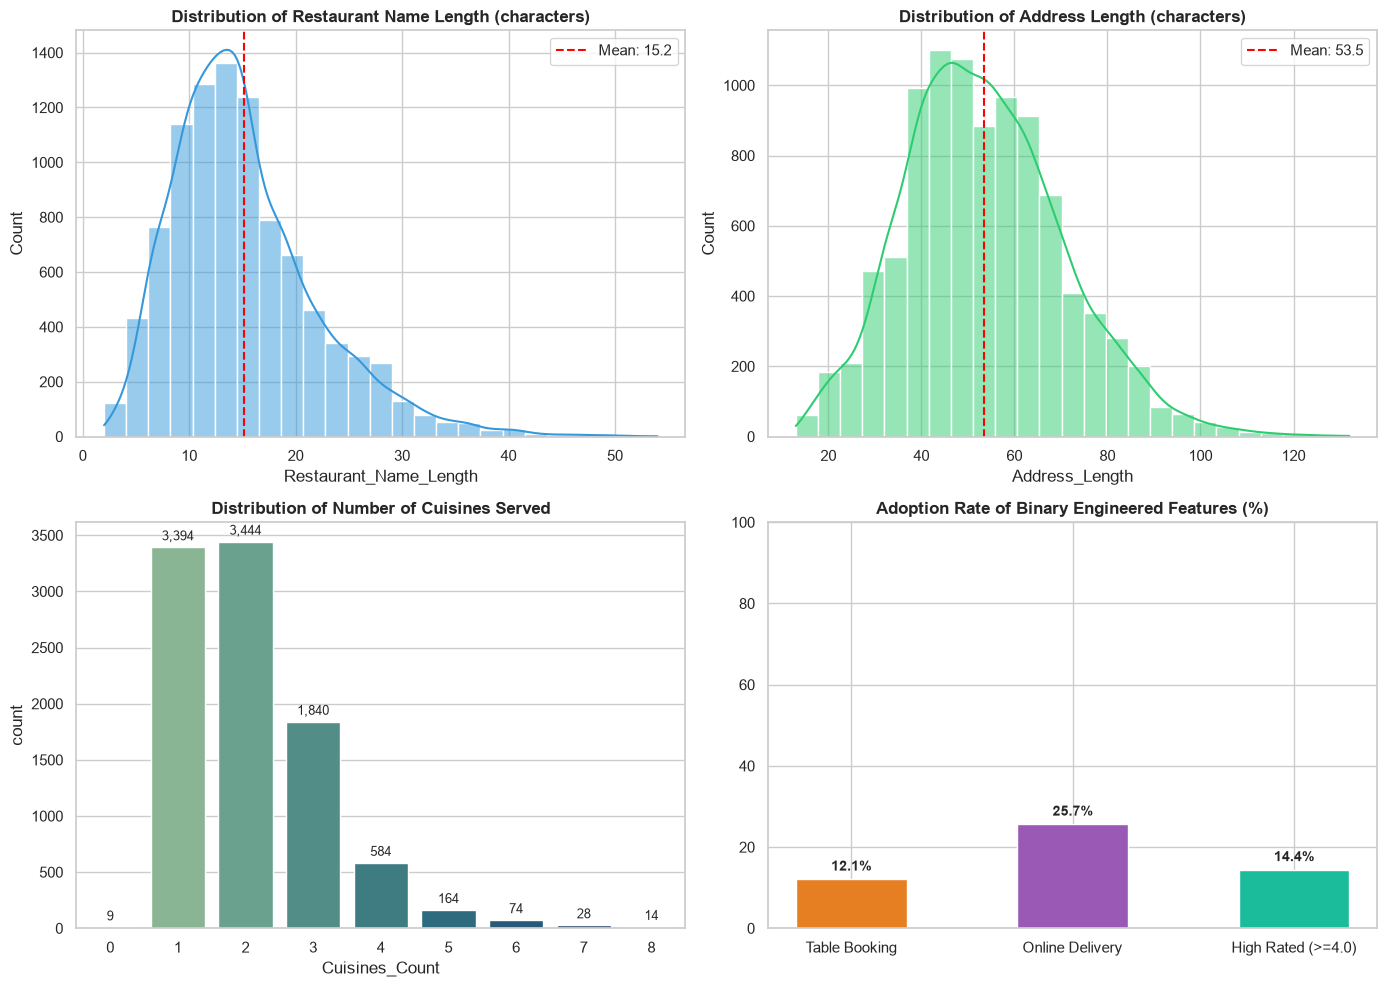

In [20]:
# Visualization 6: Feature Engineered Distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Restaurant Name Length
sns.histplot(fe_df['Restaurant_Name_Length'], bins=25, kde=True, color='#3498db', ax=axes[0, 0])
axes[0, 0].set_title("Distribution of Restaurant Name Length (characters)", weight='bold')
axes[0, 0].axvline(fe_df['Restaurant_Name_Length'].mean(), color='red', linestyle='--', label=f"Mean: {fe_df['Restaurant_Name_Length'].mean():.1f}")
axes[0, 0].legend()

# Address Length
sns.histplot(fe_df['Address_Length'], bins=25, kde=True, color='#2ecc71', ax=axes[0, 1])
axes[0, 1].set_title("Distribution of Address Length (characters)", weight='bold')
axes[0, 1].axvline(fe_df['Address_Length'].mean(), color='red', linestyle='--', label=f"Mean: {fe_df['Address_Length'].mean():.1f}")
axes[0, 1].legend()

# Cuisines Count
sns.countplot(data=fe_df, x='Cuisines_Count', hue='Cuisines_Count', legend=False, palette='crest', ax=axes[1, 0])
axes[1, 0].set_title("Distribution of Number of Cuisines Served", weight='bold')
for p in axes[1, 0].patches:
    h = p.get_height()
    if h > 0:
        axes[1, 0].annotate(f"{int(h):,}", (p.get_x() + p.get_width() / 2., h), ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')

# Adoption Rates
binary_pcts = fe_df[['Has_Table_Booking', 'Has_Online_Delivery', 'Is_High_Rated']].mean() * 100
bars = axes[1, 1].bar(['Table Booking', 'Online Delivery', 'High Rated (>=4.0)'], binary_pcts.values, color=['#e67e22', '#9b59b6', '#1abc9c'], width=0.5)
axes[1, 1].set_title("Adoption Rate of Binary Engineered Features (%)", weight='bold')
axes[1, 1].set_ylim(0, 100)
for b in bars:
    axes[1, 1].annotate(f"{b.get_height():.1f}%", (b.get_x() + b.get_width() / 2., b.get_height()), ha='center', va='bottom', fontsize=10, weight='bold', xytext=(0, 4), textcoords='offset points')

plt.tight_layout()
plt.show()


---
## Section 8: Key Findings Summary

### Task 1: Table Booking & Online Delivery
- **Table Booking Availability:** Only **12.12%** (1,158 restaurants) offer table booking, while **87.88%** (8,393 restaurants) do not.
- **Online Delivery Availability:** **25.66%** (2,451 restaurants) offer online delivery, while **74.34%** (7,100 restaurants) do not.
- **Rating Impact:** Restaurants offering table booking boast an average rating of **3.44**, compared to **2.56** for those without (a substantial +0.88 premium).
- **Delivery by Price Tier:** Online delivery adoption displays an inverted-U curve: Tier 1 (15.77%), **Tier 2 (41.31% - highest adoption)**, Tier 3 (29.19%), and Tier 4 (9.04% - lowest adoption).

### Task 2: Price Range Analysis
- **Most Common Tier:** **Price Range 1 (Budget)** is the most common with **4,444 restaurants (46.53%)**, followed by Tier 2 (3,113, 32.59%), Tier 3 (1,408, 14.74%), and Tier 4 (586, 6.14%).
- **Highest Average Rating:** **Price Range 4 (Luxury / Fine Dining)** earns the highest average rating of **3.82 / 5.0**, demonstrating a monotonic positive correlation between price tier and perceived quality.
- **Rating Color Relationship:** The official color representing the highest average rating is **'Dark Green' (mean rating 4.66)**. In Tier 4 restaurants, **45.73%** are rated in the premium Green/Dark Green tiers, compared to only **3.96%** in Tier 1.

### Task 3: Feature Engineering
- Engineered 7 clean features: `Restaurant_Name_Length`, `Address_Length`, `Has_Table_Booking`, `Has_Online_Delivery`, `Cuisines_Count`, `Is_High_Rated`, and `Is_Delivering_Now`.
- 100% data completeness verified with zero null values.
- Successfully exported engineered dataset to `outputs/feature_engineered_dataset.csv` (9,551 rows, 28 columns).


---
## Section 9: Final Conclusion

1. **Strategic Service Offerings:** Table booking is an effective differentiator associated with higher ratings. Mid-range restaurants (Price Range 2) are the primary drivers of online delivery, whereas fine-dining restaurants prioritize in-person ambiance.
2. **Pricing and Quality Alignment:** Customers associate higher price tiers with superior experiences, validated by the monotonic rise in average ratings from Tier 1 (2.00) to Tier 4 (3.82).
3. **Machine Learning Readiness:** The newly engineered features provide rich behavioral, descriptive, and service signals ready for downstream predictive modeling (e.g. predicting restaurant rating or customer volume).

---
**Project Status:** Level 2 Complete & Validated.
